In [2]:
import os
import numpy as np
import pandas as pd

# 1. Base directory (paste your copied root folder path here)
RAW_FILE = r"C:\Users\USER\Desktop\CRSV REPARATION DEFICIT IN NIGERIA\01_RAW_DATA\SVAC_3.3_complete.xlsx"

# 2. Check sheets in workbook
excel_obj = pd.ExcelFile(RAW_FILE)
print("=== WORKBOOK SHEETS ===")
print(excel_obj.sheet_names)

# 3. Load the primary dataset sheet
df = pd.read_excel(RAW_FILE, sheet_name=0)
print(f"\nTotal Dataset Records: {df.shape[0]} rows, {df.shape[1]} columns")

# 4. Standardize column names (lowercase & stripped)
df.columns = df.columns.str.strip().str.lower()

# 5. Locate geographic and actor columns
loc_col = [c for c in df.columns if c in ["location", "country", "state"]][0]
actor_col = [c for c in df.columns if "actor" in c and "type" not in c][0]
year_col = [c for c in df.columns if "year" in c][0]

# 6. Filter for Nigeria conflict records
nigeria_mask = df[loc_col].astype(str).str.contains("nigeria", case=False, na=False)
df_ng = df[nigeria_mask].copy()

print(f"\n=== NIGERIA OBSERVATIONS ===")
print(f"Total Actor-Years Documented: {len(df_ng)}")
print(f"Time Horizon: {df_ng[year_col].min()} to {df_ng[year_col].max()}")

# 7. List unique armed actors tracked in Nigeria
print(f"\nDocumented Armed Actors in Nigeria:")
for a in sorted(df_ng[actor_col].unique()):
    print(f"  - {a}")

# 8. Identify key sexual violence prevalence & form columns
# (SVAC uses 'state_prev', 'ai_prev', 'hrw_prev', or composite 'conf_sv')
sv_cols = [c for c in df.columns if any(k in c for k in ["prev", "conf_sv", "form", "postc"])]
print(f"\nIdentified Sexual Violence Variables ({len(sv_cols)}):")
print(sv_cols)

# 9. Quick preview of Nigeria records with reported violence
# SVAC coding: 0 = None; 1 = Isolated (<25); 2 = Frequent (25-999); 3 = Massive (1,000+)
prev_score_cols = [c for c in sv_cols if "prev" in c]
if prev_score_cols:
    active_reports = df_ng[(df_ng[prev_score_cols] > 0).any(axis=1)]
    print(f"\nActor-Years with Documented Violations: {len(active_reports)}")
    display_cols = [year_col, actor_col] + prev_score_cols
    print(active_reports[display_cols].sort_values(by=year_col, ascending=False).head(10))

=== WORKBOOK SHEETS ===
['Sheet1']

Total Dataset Records: 12876 rows, 19 columns

=== NIGERIA OBSERVATIONS ===
Total Actor-Years Documented: 151
Time Horizon: 1996 to 2023

Documented Armed Actors in Nigeria:
  -  Cameroon
  -  Chad
  -  Niger
  -  Nigeria
  - Ahlul Sunnah Jamaa
  - Cameroon
  - Chad
  - IPOB
  - IS
  - Icelanders a.k.a Niger Delta Vigilante
  - JAS
  - Jama'atu Ahlis Sunna Lidda'a watiwal-Jihad
  - Jama'atu Ahlis Sunna Lidda'awati wal-Jihad
  - Jama'atu Ahlis Sunna Lidda'awati wal-Jihad (Boko Haram)
  - NDPVF
  - Neighbourhood Watch a.k.a Vigilante Groups
  - Niger
  - Nigeria

Identified Sexual Violence Variables (6):
['postc', 'state_prev', 'ai_prev', 'hrw_prev', 'child_prev', 'form']

Actor-Years with Documented Violations: 33
       year                                       actor  state_prev  ai_prev  \
11992  2023                                          IS         2.0      0.0   
3084   2023                                         JAS         2.0      1.0   
3

In [3]:
# 1. Clean missing value indicators (-99 is SVAC's standard code for missing/unreported)
score_cols = ['state_prev', 'ai_prev', 'hrw_prev', 'child_prev']
for col in score_cols:
    df_ng[col] = df_ng[col].replace(-99, np.nan).fillna(0)

# 2. Derive a robust composite prevalence metric (Maximum reported severity across monitors)
df_ng['max_prevalence'] = df_ng[['state_prev', 'ai_prev', 'hrw_prev']].max(axis=1)

# 3. Categorize Armed Actors into Strategic Stakeholder Groups
def categorize_actor(name):
    name_low = str(name).lower()
    if 'nigeria' in name_low and 'delta' not in name_low:
        return 'State Security Forces (Nigeria)'
    elif any(k in name_low for k in ['jama', 'jas', 'boko', 'is', 'ahlul']):
        return 'Non-State Armed Groups (Boko Haram / ISWAP)'
    elif any(k in name_low for k in ['vigilante', 'neighbourhood', 'watch', 'icelanders', 'ndpvf', 'ipob']):
        return 'Militias, Vigilantes & Auxiliary Groups'
    elif any(k in name_low for k in ['cameroon', 'chad', 'niger']):
        return 'Regional Coalition Partners (MNJTF)'
    return 'Other Armed Actor'

df_ng['actor_category'] = df_ng[actor_col].apply(categorize_actor)

# 4. Map Prevalence Scores to Qualitative Impact Labels
# 0 = None; 1 = Isolated (<25); 2 = Frequent (25-999); 3 = Massive (1,000+)
prev_labels = {
    0: '0 - None Documented',
    1: '1 - Isolated (<25)',
    2: '2 - Frequent / Numerous (25-999)',
    3: '3 - Massive / Systematic (1,000+)'
}
df_ng['prevalence_label'] = df_ng['max_prevalence'].map(prev_labels)

# 5. Map the 4 Transitional Justice Pillars (Analytical Indicators for Power BI)
# CRSV generates specific structural harms requiring administrative redress:
df_ng['requires_rehabilitation'] = df_ng['max_prevalence'].apply(lambda x: 1 if x > 0 else 0)
df_ng['requires_compensation'] = df_ng['max_prevalence'].apply(lambda x: 1 if x >= 1 else 0)
df_ng['child_vulnerability_flag'] = df_ng['child_prev'].apply(lambda x: 'High Child Risk' if x >= 2 else ('Documented Risk' if x == 1 else 'None'))

print("=== DATA TRANSFORMATION COMPLETE ===")
print("Summary of Maximum Documented Prevalence in Nigeria:")
print(df_ng['prevalence_label'].value_counts())
print("\nBreakdown by Strategic Actor Category:")
print(pd.crosstab(df_ng['actor_category'], df_ng['prevalence_label'], margins=True))

=== DATA TRANSFORMATION COMPLETE ===
Summary of Maximum Documented Prevalence in Nigeria:
prevalence_label
0 - None Documented                  118
2 - Frequent / Numerous (25-999)      18
3 - Massive / Systematic (1,000+)     10
1 - Isolated (<25)                     5
Name: count, dtype: int64

Breakdown by Strategic Actor Category:
prevalence_label                             0 - None Documented  \
actor_category                                                     
Militias, Vigilantes & Auxiliary Groups                       21   
Non-State Armed Groups (Boko Haram / ISWAP)                   11   
Regional Coalition Partners (MNJTF)                           55   
State Security Forces (Nigeria)                               31   
All                                                          118   

prevalence_label                             1 - Isolated (<25)  \
actor_category                                                    
Militias, Vigilantes & Auxiliary Groups             

In [4]:
import os

OUTPUT_DIR = r"C:\Users\USER\Desktop\CRSV REPARATION DEFICIT IN NIGERIA\02_PROCESSED_DATA"

# 1. Main detailed analytical dataset
output_file = os.path.join(OUTPUT_DIR, "CRSV_Nigeria_Clean_Analytical_Dataset.csv")
df_ng.to_csv(output_file, index=False)
print(f"Exported clean analytical dataset to:\n{output_file}")

# 2. Aggregated Actor Profile for Quick Power BI Card & Matrix Visuals
actor_summary = df_ng[df_ng['max_prevalence'] > 0].groupby(['actor_category', actor_col]).agg(
    total_violation_years=('year', 'count'),
    peak_prevalence=('max_prevalence', 'max'),
    peak_child_prevalence=('child_prev', 'max'),
    start_year=('year', 'min'),
    end_year=('year', 'max')
).reset_index()

summary_file = os.path.join(OUTPUT_DIR, "CRSV_Nigeria_Actor_Profile_Summary.csv")
actor_summary.to_csv(summary_file, index=False)
print(f"\nExported actor summary table to:\n{summary_file}")

Exported clean analytical dataset to:
C:\Users\USER\Desktop\CRSV REPARATION DEFICIT IN NIGERIA\02_PROCESSED_DATA\CRSV_Nigeria_Clean_Analytical_Dataset.csv

Exported actor summary table to:
C:\Users\USER\Desktop\CRSV REPARATION DEFICIT IN NIGERIA\02_PROCESSED_DATA\CRSV_Nigeria_Actor_Profile_Summary.csv


## 2. Longitudinal CRSV Trends & Perpetrator Accountability (1996–2023)
Here we examine the temporal trajectory of sexual violence in Nigeria, contrasting non-state insurgent groups with state actors, alongside the prevalence of sexual violence targeting children.

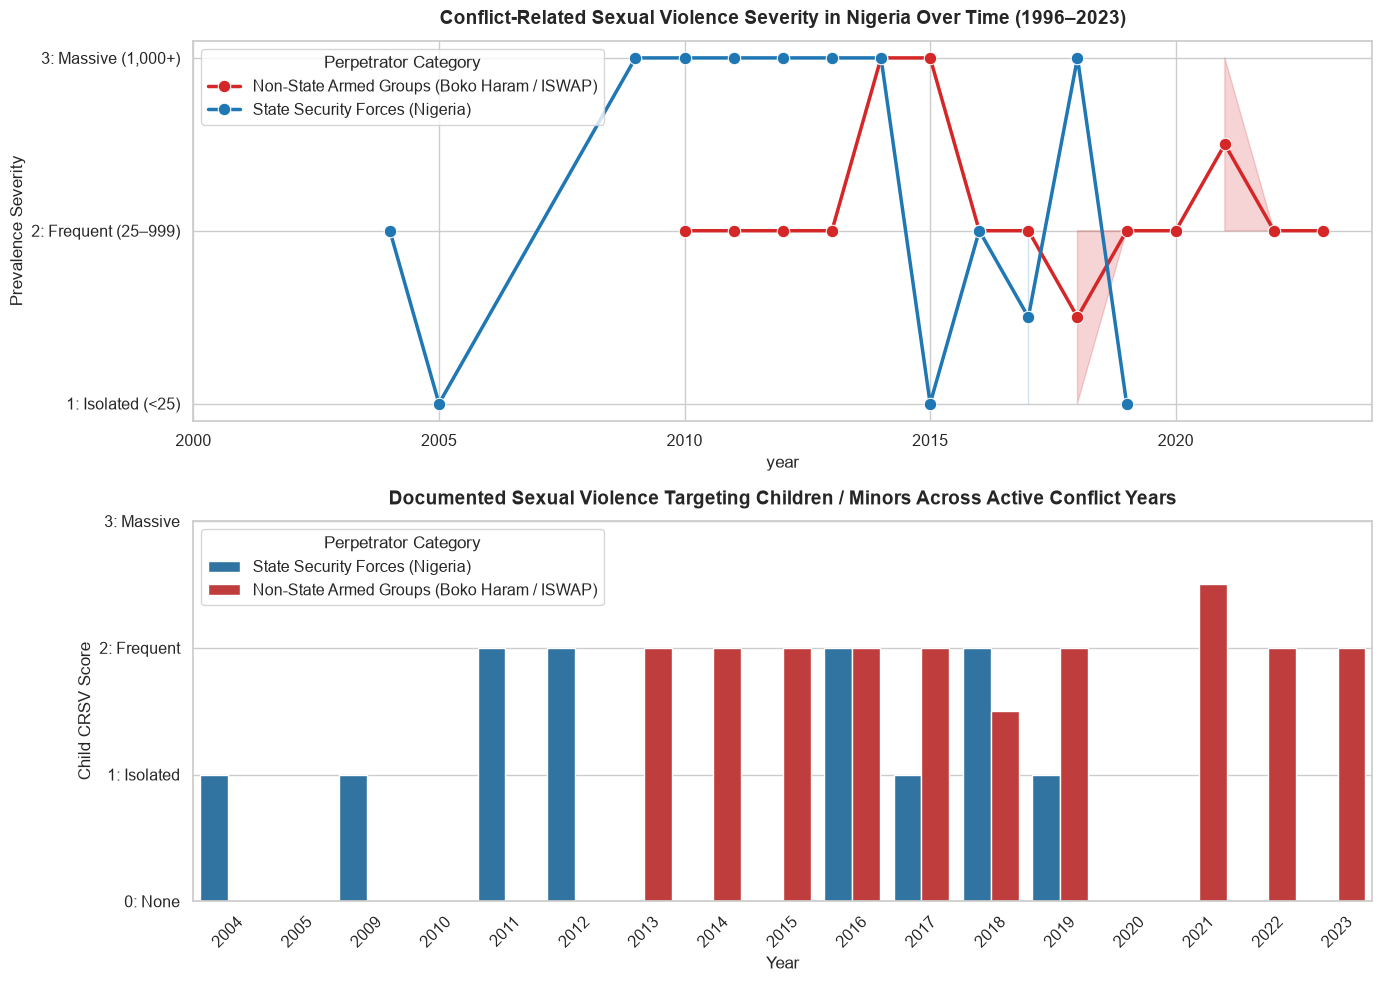

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean aesthetic styling
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

active_df = df_ng[df_ng['max_prevalence'] > 0].copy()
active_df['year'] = active_df['year'].astype(int)

# Palette mapping for clean contrast
palette_map = {
    'State Security Forces (Nigeria)': '#1f77b4',
    'Non-State Armed Groups (Boko Haram / ISWAP)': '#d62728',
    'Militias, Vigilantes & Auxiliary Groups': '#2ca02c',
    'Regional Coalition Partners (MNJTF)': '#9467bd',
}

# 1. Trajectory of Overall CRSV Severity
sns.lineplot(
    data=active_df,
    x='year',
    y='max_prevalence',
    hue='actor_category',
    marker='o',
    markersize=9,
    linewidth=2.5,
    ax=axes[0],
    palette=palette_map,
)
axes[0].set_title(
    'Conflict-Related Sexual Violence Severity in Nigeria Over Time (1996–2023)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
axes[0].set_ylabel('Prevalence Severity', fontsize=12)
axes[0].set_yticks([1, 2, 3])
axes[0].set_yticklabels(
    ['1: Isolated (<25)', '2: Frequent (25–999)', '3: Massive (1,000+)']
)
axes[0].set_xlim(2000, 2024)
axes[0].legend(title='Perpetrator Category', loc='upper left')

# 2. Child Vulnerability & Targeting Over Time
sns.barplot(
    data=active_df,
    x='year',
    y='child_prev',
    hue='actor_category',
    ax=axes[1],
    palette=palette_map,
    errorbar=None,
)
axes[1].set_title(
    'Documented Sexual Violence Targeting Children / Minors Across Active Conflict Years',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Child CRSV Score', fontsize=12)
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(
    ['0: None', '1: Isolated', '2: Frequent', '3: Massive']
)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Perpetrator Category', loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
import os

VIS_DIR = r"C:\Users\USER\Desktop\CRSV REPARATION DEFICIT IN NIGERIA\04_VISUALIZATION"

# Ensure the folder exists if named slightly differently (e.g. 04_VISUALIZATIONS)
os.makedirs(VIS_DIR, exist_ok=True)

fig.savefig(
    os.path.join(VIS_DIR, "crsv_severity_and_child_targeting_trends.png"),
    dpi=300,
    bbox_inches="tight"
)
print("Figure saved successfully to 04_VISUALIZATION!")

Figure saved successfully to 04_VISUALIZATION!
